In [137]:
# Banking Transaction Analytics with Fraud Detection

Business Problem

Banks process thousands of transactions daily across multiple branches, making it challenging to:

Monitor customer behaviour
Identify high-value customers
Detect potentially fraudulent transactions in real time
Evaluate branch performance

This project demonstrates how data analytics can support risk management, customer segmentation, and operational decision-making in banking systems.

Analytical Approach
Data cleaning and preprocessing
Exploratory data analysis (EDA)
Customer behaviour analysis
Customer segmentation (K-Means clustering)
Fraud detection (anomaly detection)
Insights and recommendations

Dataset Overview
TransactionID: Unique transaction identifier
CustomerID: Unique customer identifier
Branch: Bank branch location
Date: Transaction date
TransactionType: Credit / Debit
Amount: Transaction value
AccountBalance: Balance after transaction

Tools and Libraries


In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Load Data

In [139]:
transactions = pd.read_csv('transactions_cleaned.csv')

transactions.columns = transactions.columns.str.strip()

print(transactions.columns)
transactions.head()

Index(['Transaction_ID', 'Account_ID', 'Date', 'Transaction_Type', 'Amount',
       'Branch', 'Status', 'Year', 'Month'],
      dtype='object')


,Transaction_ID,Account_ID,Date,Transaction_Type,Amount,Branch,Status,Year,Month
0,1001,533,2026-01-31,Deposit,4989,Birmingham,Success,2026,1
1,1002,543,2026-01-29,Withdrawal,2015,Birmingham,Success,2026,1
2,1003,538,2026-01-31,Deposit,1793,Manchester,Success,2026,1
3,1004,525,2026-02-03,Deposit,5267,Manchester,Success,2026,2
4,1005,538,2026-01-26,Withdrawal,3555,Manchester,Success,2026,1


Data Cleaning

In [140]:
rename_map = {
    'Account_ID': 'CustomerID',
    'Transaction_Type': 'TransactionType',
    'Transaction_ID': 'TransactionID'
}

transactions.rename(columns={k: v for k, v in rename_map.items() if k in transactions.columns}, inplace=True)

transactions.info()
transactions.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TransactionID    50 non-null     int64 
 1   CustomerID       50 non-null     int64 
 2   Date             50 non-null     object
 3   TransactionType  50 non-null     object
 4   Amount           50 non-null     int64 
 5   Branch           50 non-null     object
 6   Status           50 non-null     object
 7   Year             50 non-null     int64 
 8   Month            50 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 3.6+ KB


TransactionID      0
CustomerID         0
Date               0
TransactionType    0
Amount             0
Branch             0
Status             0
Year               0
Month              0
dtype: int64

Exploratory Data Analysis (EDA)
 Branch Performance

In [141]:
branch_totals = transactions.groupby('Branch')['Amount'].sum().reset_index()
branch_totals

,Branch,Amount
0,Birmingham,112278
1,London,32757
2,Manchester,63351


Top Customers

In [142]:
customer_totals = transactions.groupby('CustomerID')['Amount'].sum().reset_index()
customer_totals = customer_totals.sort_values(by='Amount', ascending=False)

customer_totals.head(10)

,CustomerID,Amount
0,501,23237
14,529,17334
15,530,13349
23,539,12710
29,549,12114
26,544,10395
11,523,10232
12,525,9987
9,519,8762
25,543,7943


Transaction Distribution

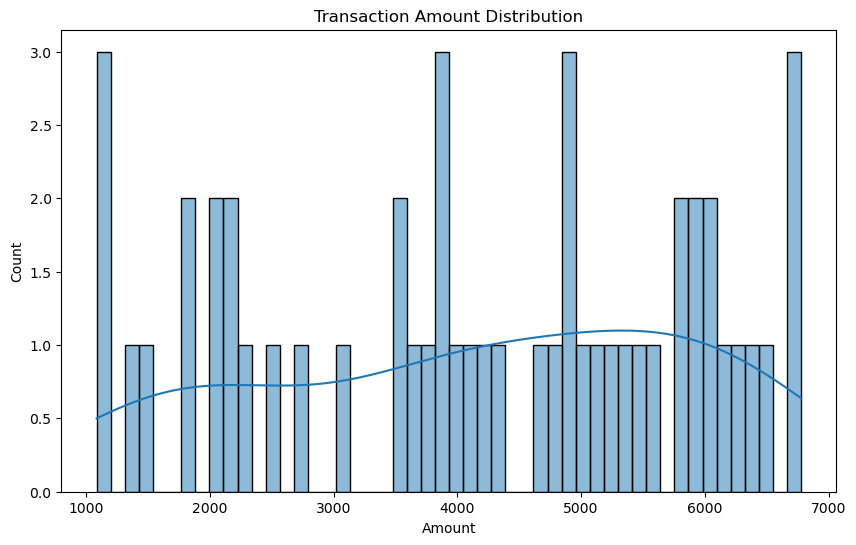

In [143]:
plt.figure(figsize=(10,6))
sns.histplot(transactions['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()

Branch Activity

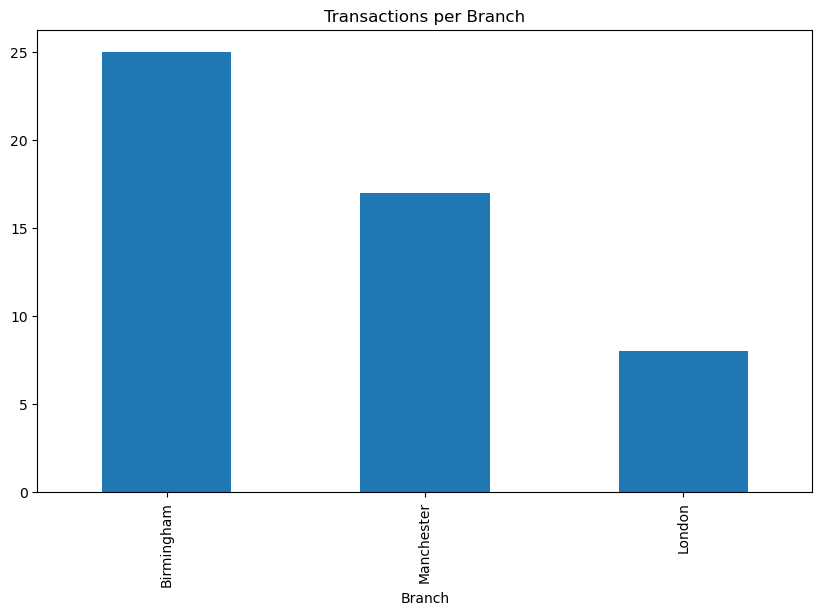

In [144]:
transactions['Branch'].value_counts().plot(kind='bar', figsize=(10,6))
plt.title("Transactions per Branch")
plt.show()

Monthly Trends

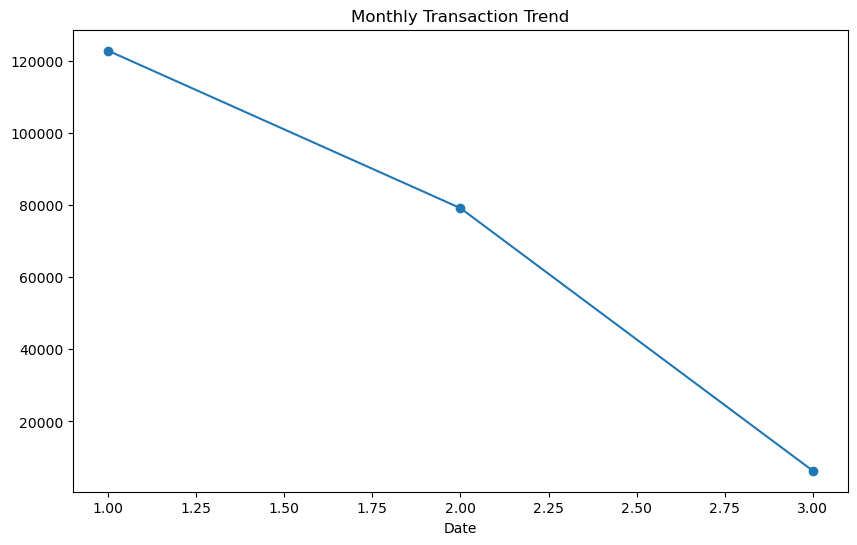

In [145]:
transactions['Date'] = pd.to_datetime(transactions['Date'])

monthly = transactions.groupby(transactions['Date'].dt.month)['Amount'].sum()

monthly.plot(marker='o', figsize=(10,6))
plt.title("Monthly Transaction Trend")
plt.show()

Transaction Type Analysis

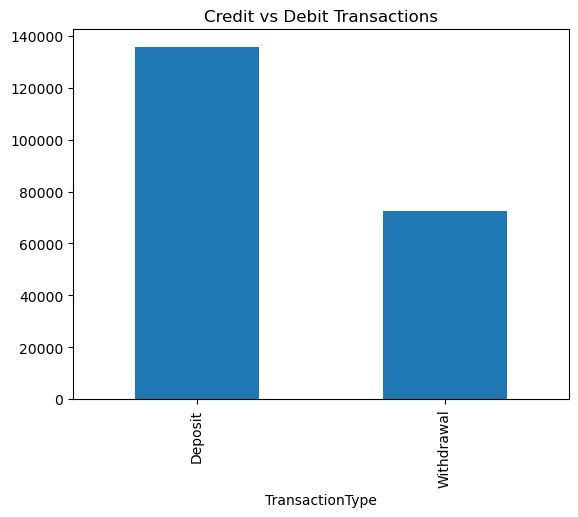

In [146]:
transactions.groupby('TransactionType')['Amount'].sum().plot(kind='bar')
plt.title("Credit vs Debit Transactions")
plt.show()

Customer Segmentation (K-Means)

In [147]:
customer_features = transactions.groupby('CustomerID')[['Amount']].agg(['mean', 'sum', 'count'])
customer_features.columns = ['AvgAmount', 'TotalAmount', 'TxnCount']
customer_features = customer_features.reset_index()

features = customer_features[['AvgAmount', 'TotalAmount', 'TxnCount']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
customer_features['Segment'] = kmeans.fit_predict(scaled_features)

customer_features.head()

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,AvgAmount,TotalAmount,TxnCount,Segment
0,501,4647.4,23237,5,0
1,502,1771.0,1771,1,2
2,504,5844.0,5844,1,1
3,505,2788.0,2788,1,2
4,508,4318.0,4318,1,2


Fraud Detection (Anomaly Detection)

In [148]:
threshold = transactions['Amount'].quantile(0.95)

transactions['Fraud_Flag'] = transactions['Amount'] > threshold

fraud_transactions = transactions[transactions['Fraud_Flag']]

print("Number of flagged transactions:", len(fraud_transactions))
fraud_transactions.head()

Number of flagged transactions: 3


,TransactionID,CustomerID,Date,TransactionType,Amount,Branch,Status,Year,Month,Fraud_Flag
13,1014,530,2026-01-16,Deposit,6665,Birmingham,Success,2026,1,True
28,1029,549,2026-01-13,Withdrawal,6777,Birmingham,Success,2026,1,True
47,1048,530,2026-02-25,Deposit,6684,Manchester,Success,2026,2,True


Fraud Visualization

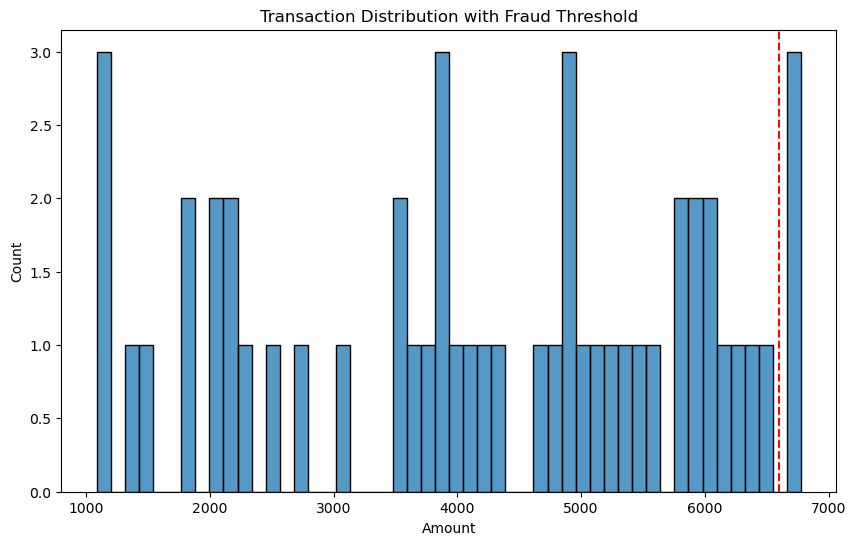

In [149]:
plt.figure(figsize=(10,6))
sns.histplot(transactions['Amount'], bins=50)
plt.axvline(threshold, linestyle='--', color='red')
plt.title('Transaction Distribution with Fraud Threshold')
plt.show()

Fraud by Branch

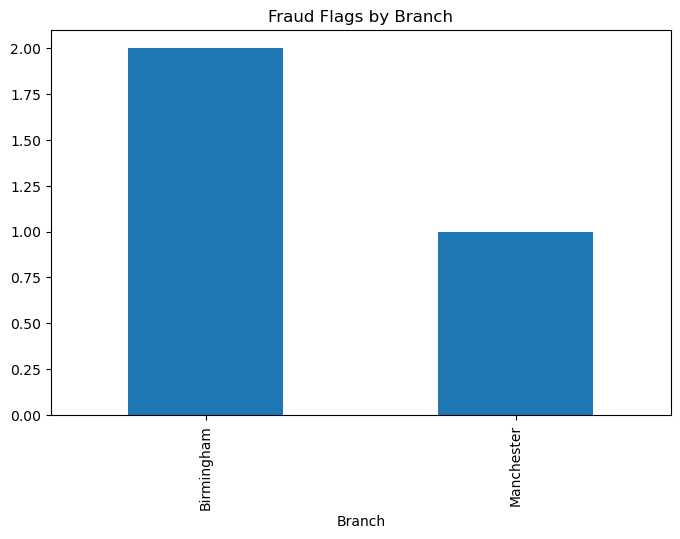

In [150]:
fraud_by_branch = fraud_transactions['Branch'].value_counts()

if not fraud_by_branch.empty:
    fraud_by_branch.plot(kind='bar', figsize=(8,5))
    plt.title('Fraud Flags by Branch')
    plt.show()
else:
    print("No fraud detected")

Key Insights
Transaction volume varies significantly across branches
A small group of customers contributes to most transaction value
High-value transactions are rare but important for fraud detection
Customer segmentation helps identify behavioural patterns
Branch-level monitoring highlights operational differences
Recommendations
Implement real-time fraud monitoring using dynamic thresholds
Focus on high-value customers for retention strategies
Investigate branches with unusually high transaction activity
Improve fraud detection using advanced ML models (Isolation Forest, XGBoost)
Use segmentation for personalized banking products
 Business Value

This project demonstrates how data analytics can support:

Fraud detection and risk management
Customer segmentation and targeting
Branch performance evaluation
Data-driven decision-making in banking operations
